# GeoBench DynamicEarthNet

## Intro

Dynamic EarthNet [(Toker et al. 2022)](https://arxiv.org/abs/2203.12560) is a large-scale dataset for spatio-temporal Earth surface predictions using multi-modal satellite data. The combination of daily Planet Labs high-resolution imagery and Sentinel-2 multispectral imagery, paired with pixel-wise semantic segmentation labels of 7 land use and land cover (LULC) classes aim to advance efforts of land use evolution monitoring.

## Dataset Characteristics

- **Modalities**: 
  - Sentinel-2 optical imagery (10 spectral bands)
  - Planet high-resolution imagery (4 bands)
- **Spatial Resolution**: 
  - S2: 10m ground sample distance
  - Planet: ~3m ground sample distance
- **Temporal Resolution**: Daily observations of planet data
- **Spectral Bands**: 
  - S2: 10 bands (B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12)
  - Planet: RGB + NIR (4 bands)
- **Image Dimensions**: 512x512 pixels per patch (5.12km x 5.12km)
- **Labels**: 7-class land cover segmentation masks for spatio-temporal predictions
  - Class 0: Impervious surfaces
  - Class 1: Agriculture  
  - Class 2: Forest & other vegetation
  - Class 3: Wetlands
  - Class 4: Soil
  - Class 5: Water
  - Class 6: Snow & ice
- **Temporal Coverage**: Multi-year sequences (2016-2019) with monthly time series
- **Task**: Spatio-temporal prediction of land surface states


## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Patch Generation**
   - Original tiles of 1024x1024 were split into 4 512x512 patches

2. **Split Generation**:
   - Applied location-based splitting to the unique locations
   - Used 8x8 geographic binning across globe to ensure global representation in each split
   - Implemented space-time disjointedness: same locations never appear across different splits
   - Rebalanced splits to guarantee geographic diversity while maintaining temporal independence

3. **Dataset Subsamping**:
   - The final version consists of
      - 4,000 training samples
      - 1,000 validation samples
      - 2,000 test samples

## References

1. Toker, A., Kondmann, L., Weber, M., Eisenberger, M., Camero, A., Hu, J., Hoderlein, A.P., Şenaras, Ç., Davis, T., Cremers, D. and Marchisio, G., 2022. Dynamicearthnet: Daily multi-spectral satellite dataset for semantic change segmentation. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 21158-21167).

In [1]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchDynamicEarthNetDataModule
from geobench_v2.datasets import GeoBenchDynamicEarthNet
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer
from geobench_v2.datasets.visualization_util import (
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

# %load_ext autoreload
# %autoreload 2

In [2]:
DATA_ROOT = Path("../../data/dynamic_earthnet")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "dynamic_earthnet_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(
    DATA_ROOT, "dynamic_earthnet_stats_clip_rescale.json"
)

In [3]:
band_order = GeoBenchDynamicEarthNet.band_default_order

datamodule = GeoBenchDynamicEarthNetDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    temporal_setting="weekly",
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


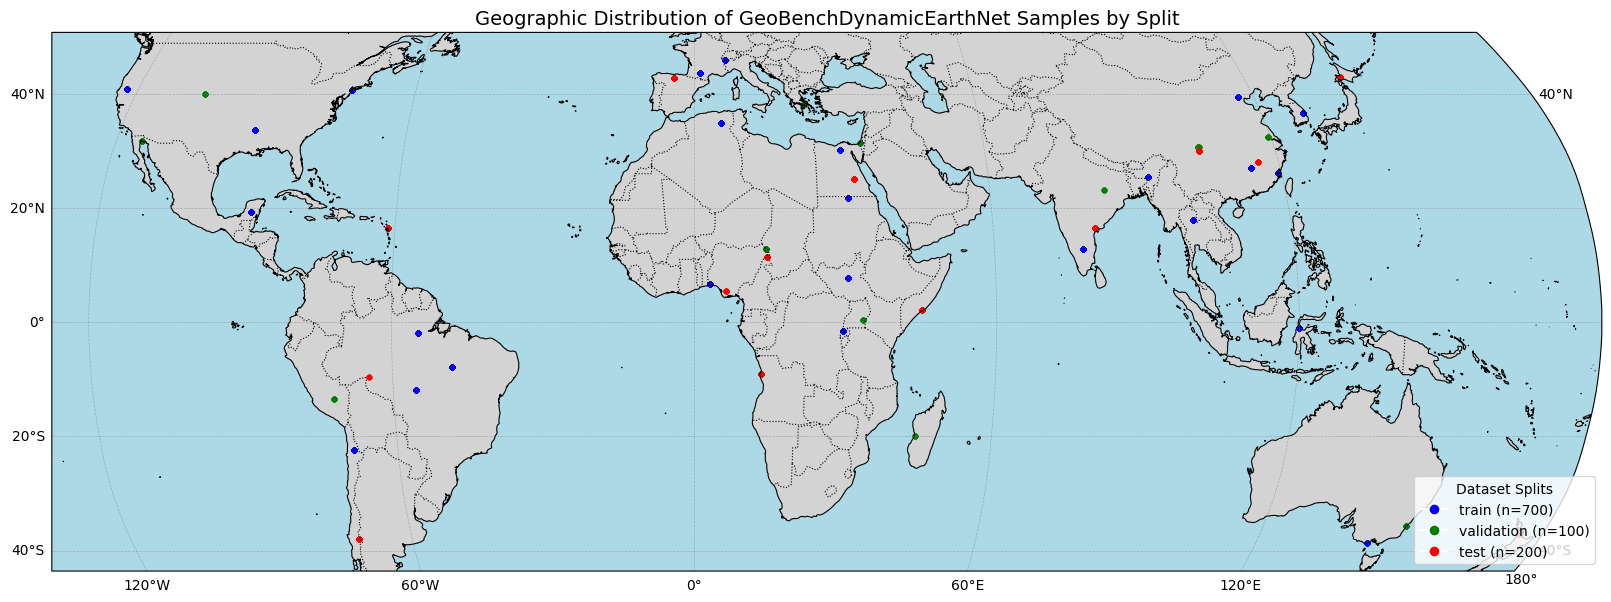

In [4]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

### Raw Image Statistics

Computed over the training dataset.

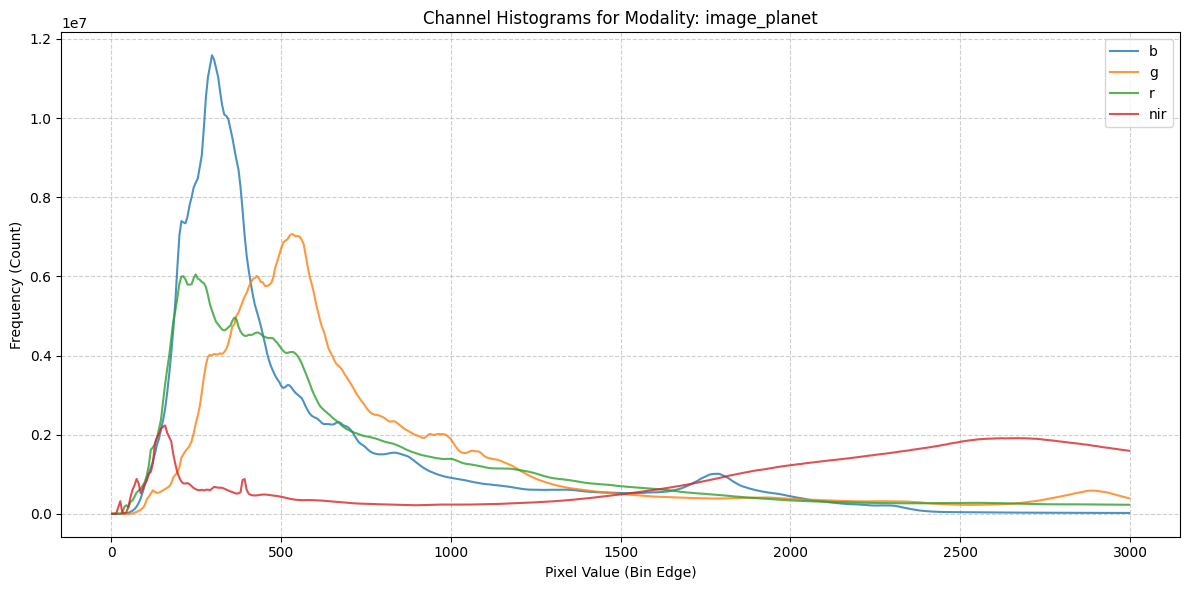

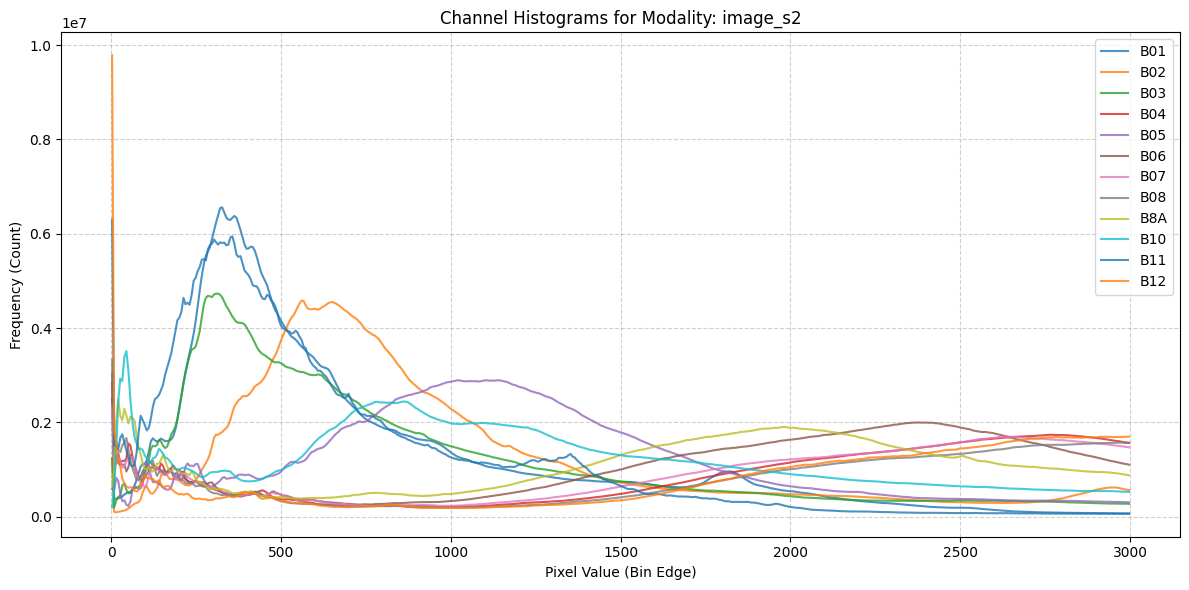

In [5]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

## Target Statistics

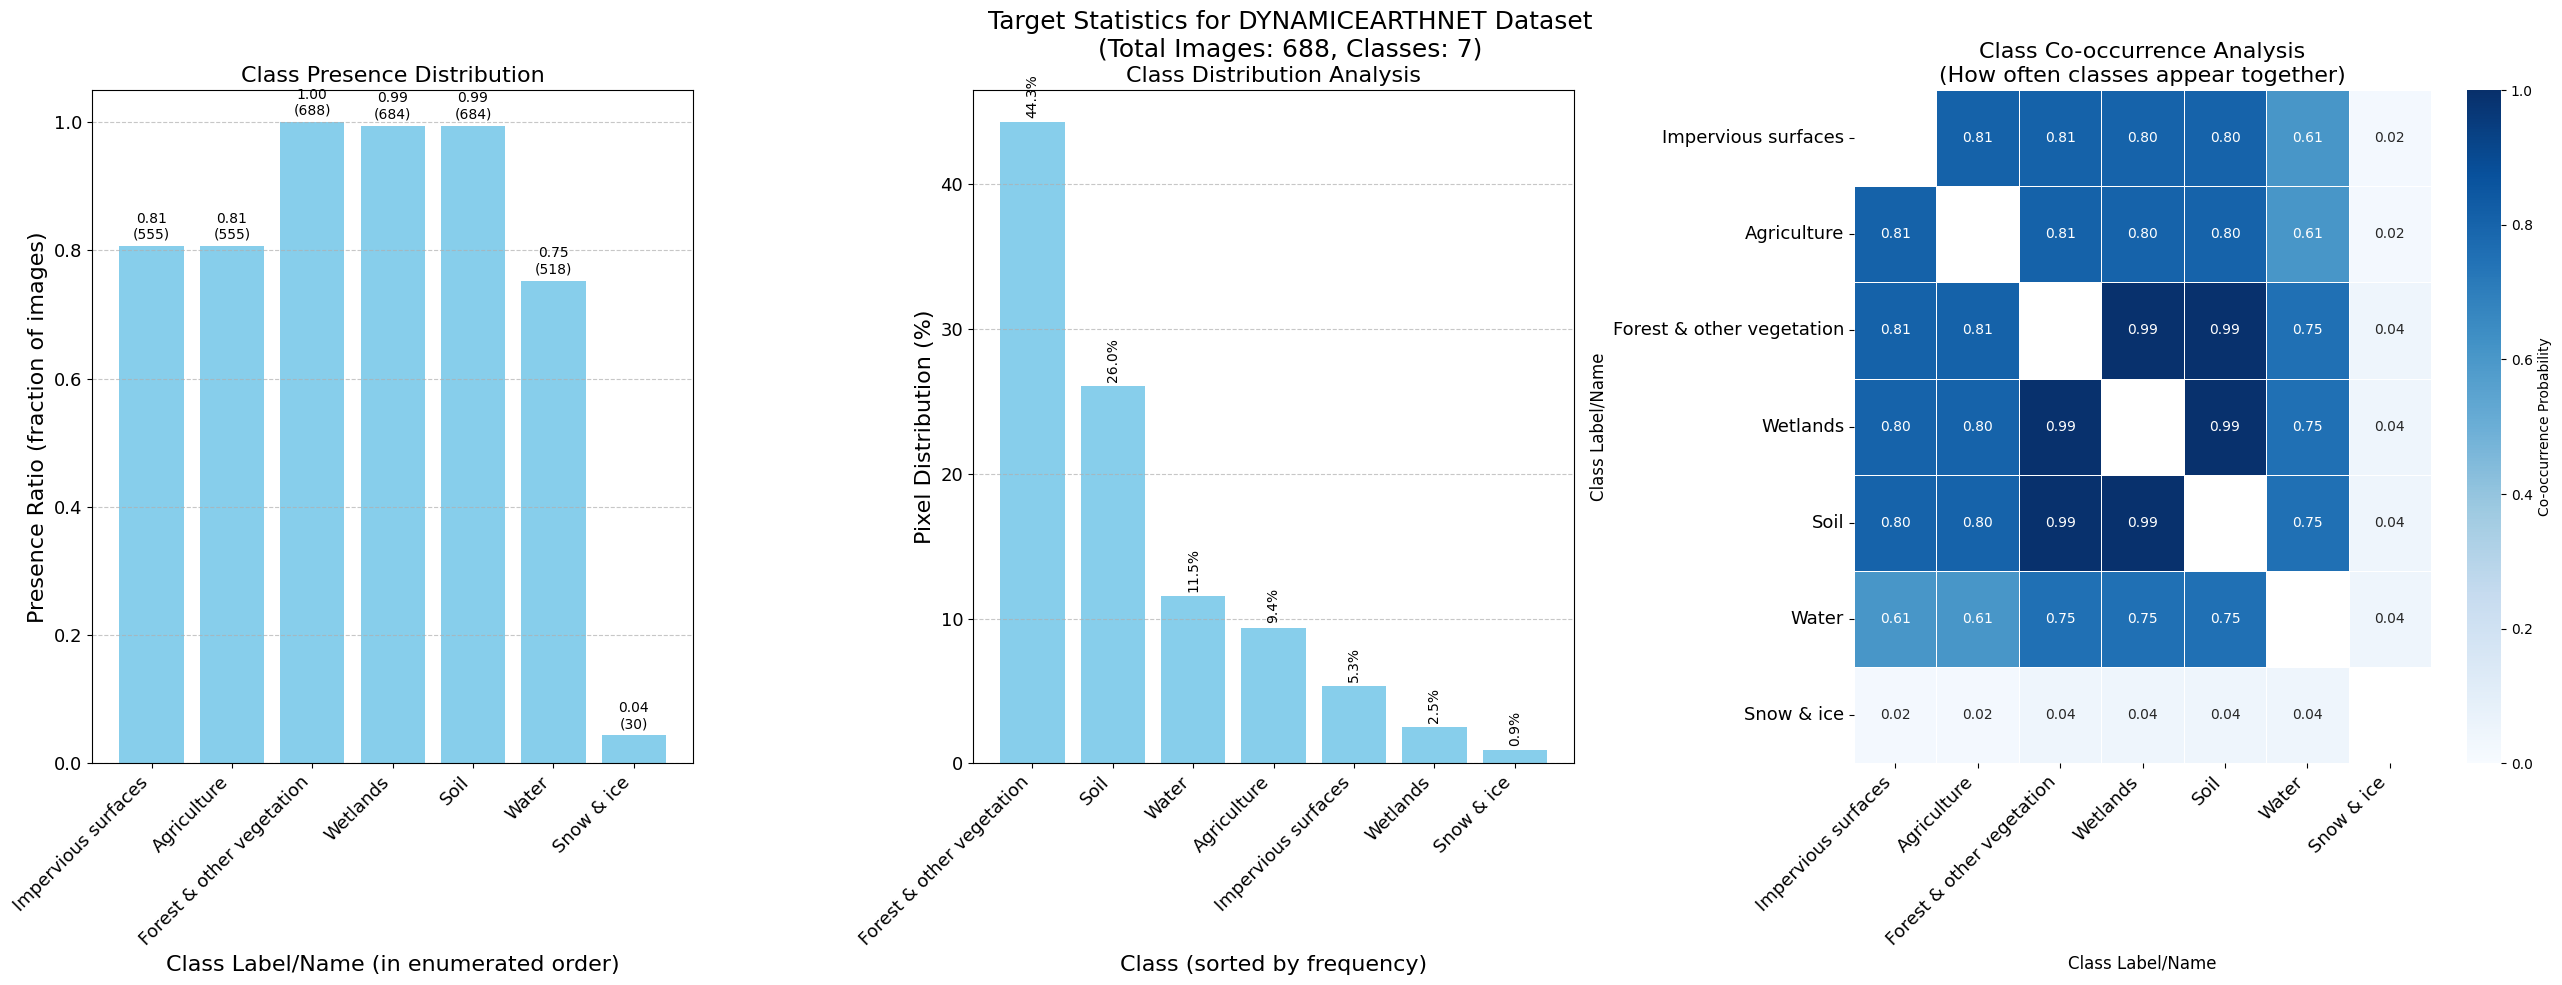

In [6]:
fig = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "DynamicEarthNet")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>, <Figure size 1200x500 with 1 Axes>]

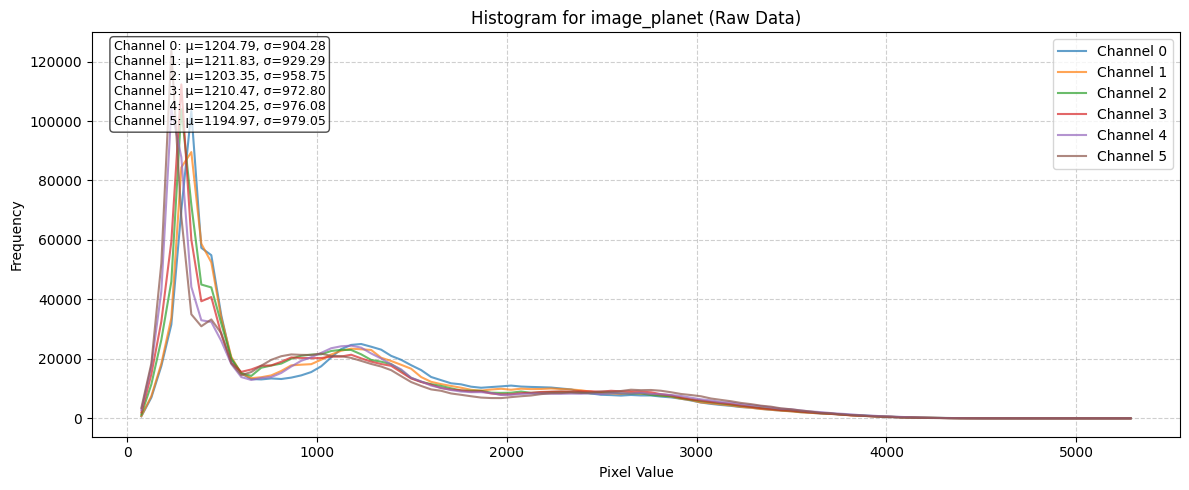

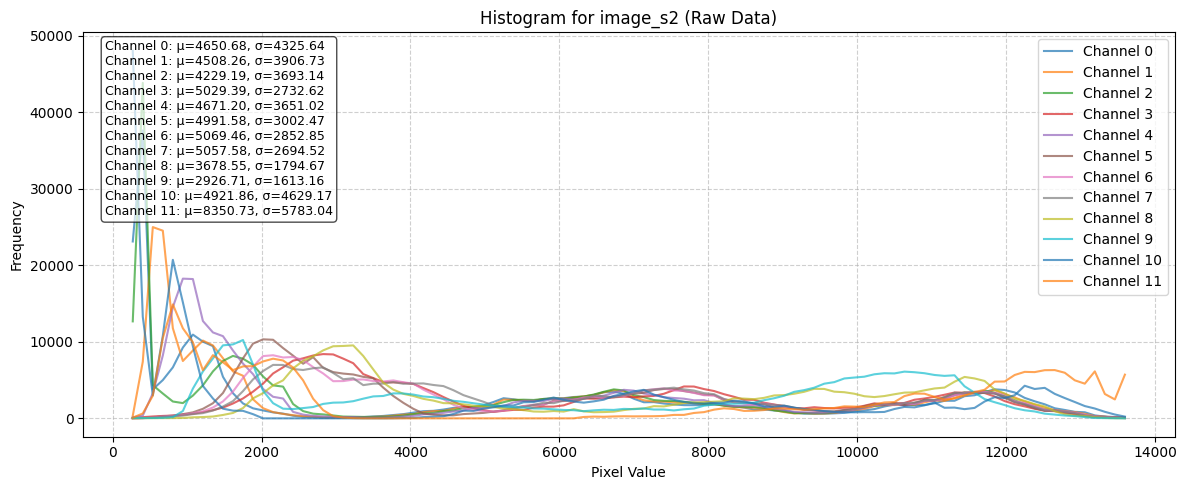

In [7]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of Normalization Schemes

In [8]:
clip_z_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

### Effect of SatMAE Normalization scheme on batch

[<Figure size 1200x500 with 1 Axes>, <Figure size 1200x500 with 1 Axes>]

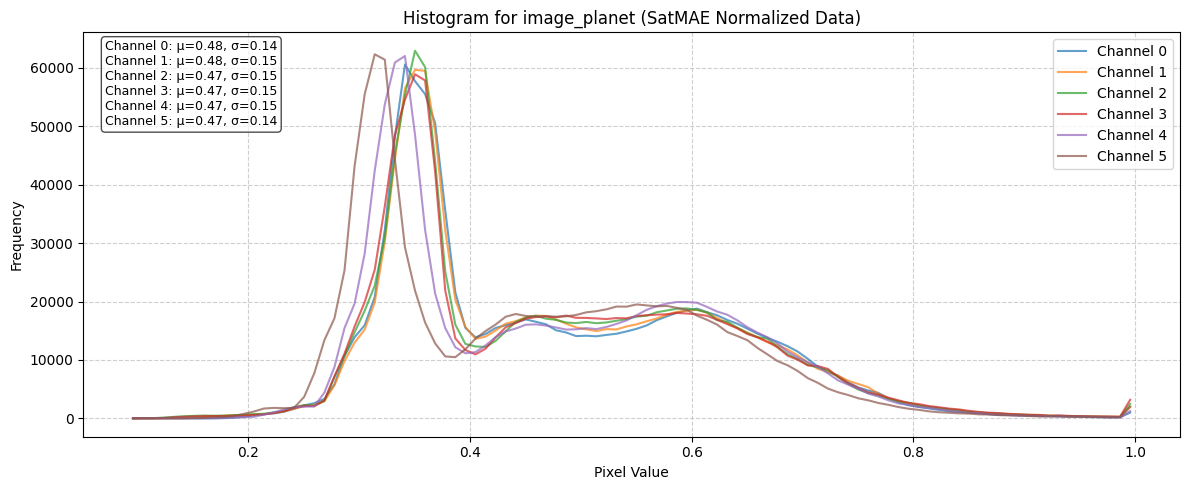

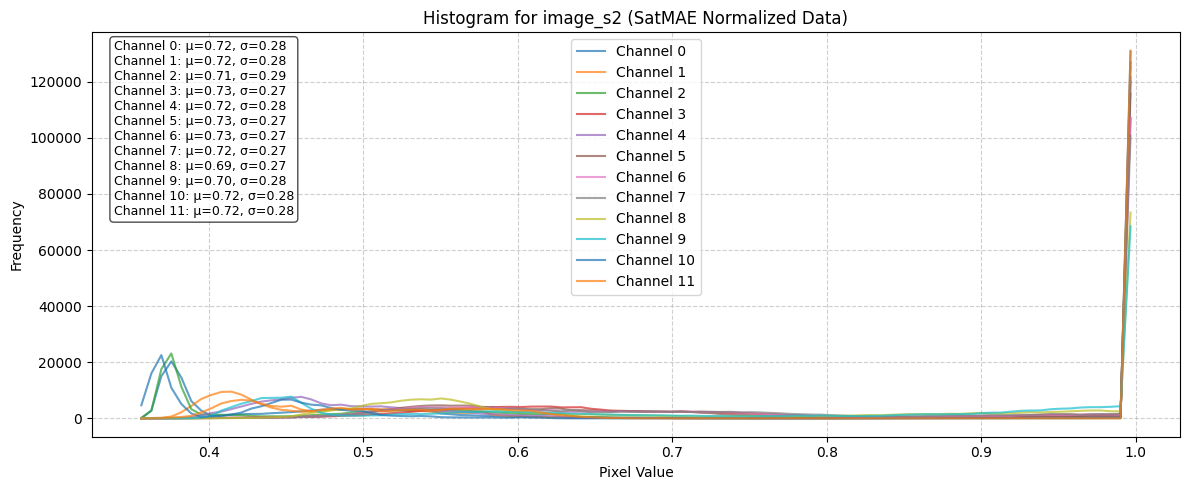

In [9]:
satmae_normalized_batch = satmae_normalizer(raw_batch)
satmae_batch_stats = compute_batch_histograms(satmae_normalized_batch, n_bins=100)
sat_mae_norm_fig = plot_batch_histograms(
    satmae_batch_stats, band_order, title_suffix=" (SatMAE Normalized Data)"
)
sat_mae_norm_fig

### Effect of ClipZ Normalization scheme on batch

[<Figure size 1200x500 with 1 Axes>, <Figure size 1200x500 with 1 Axes>]

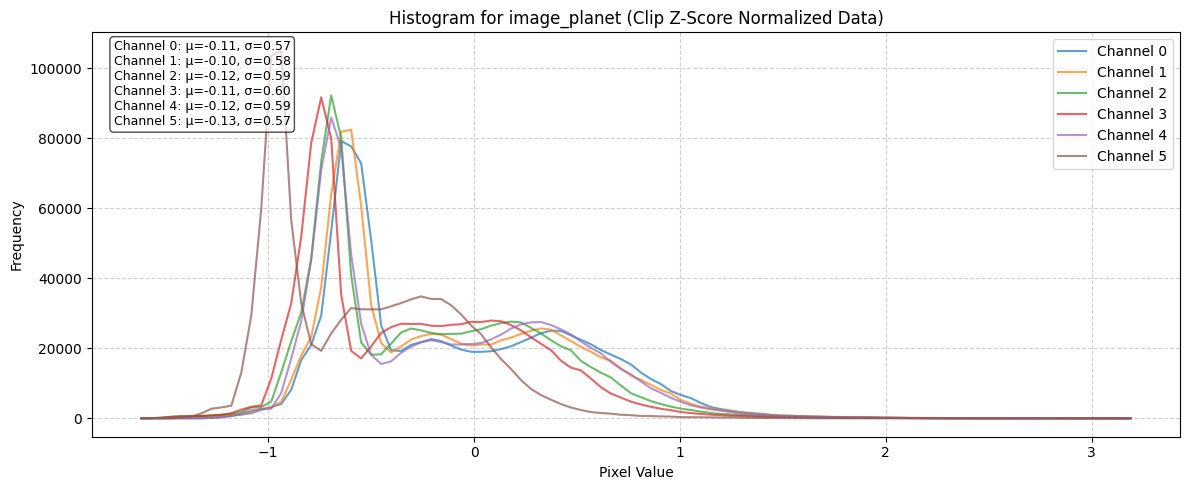

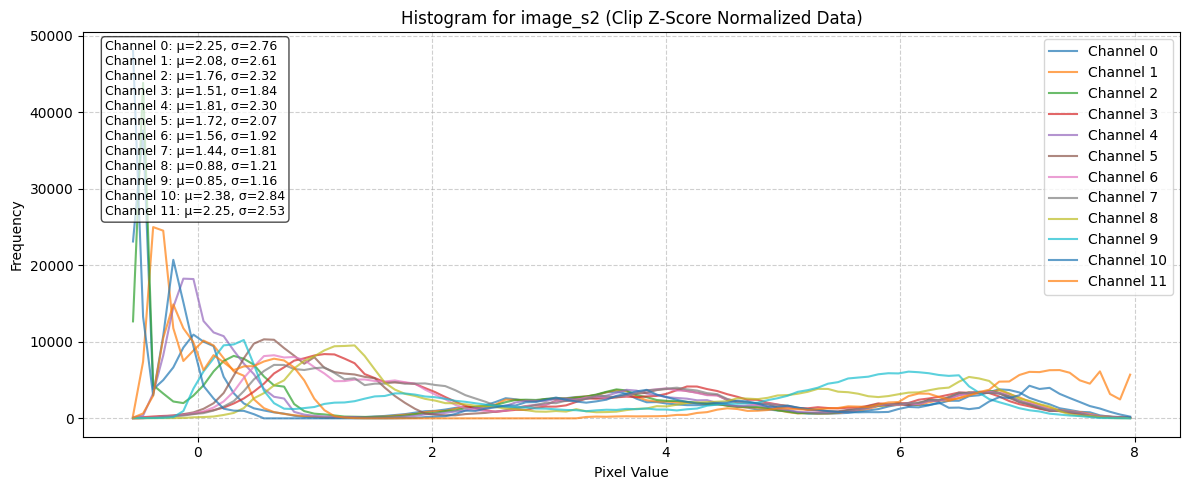

In [10]:
clip_z_normalized_batch = clip_z_normalizer(raw_batch)
clip_z_batch_stats = compute_batch_histograms(clip_z_normalized_batch, n_bins=100)
clip_z_norm_fig = plot_batch_histograms(
    clip_z_batch_stats, band_order, title_suffix=" (Clip Z-Score Normalized Data)"
)
clip_z_norm_fig

## Visualize Batch Data

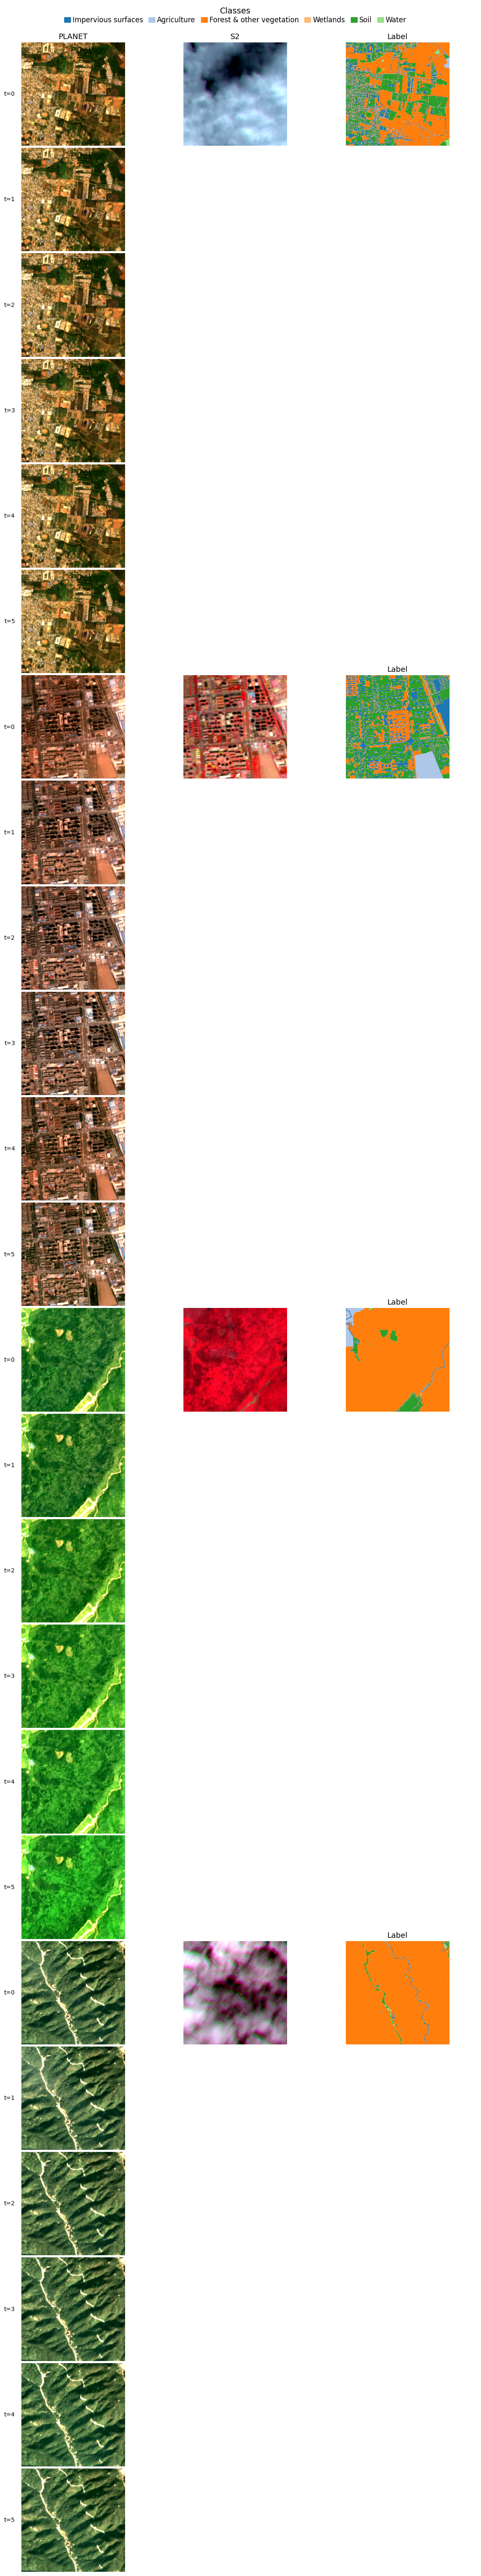

In [11]:
fig, batch = datamodule.visualize_batch(raw_batch)